In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict
import seaborn as sns

In [3]:
df = pd.read_csv(filepath_or_buffer="players.csv")

In [4]:
df.head()

,player_id,common_name,first_name,last_name,overall_rating,position,alternate_positions,club,league,nationality,...,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes,edition,snapshot_date
0,227203,Alexia Putellas,Alexia,Putellas Segura,91,CM,CAM ST,London City,Barclays WSL,Spain,...,60,82,64,15,17,11,15,10,fc27,2026-09-12
1,231747,NaN,Kylian,Mbappé,91,ST,LW,Real Madrid,LALIGA EA SPORTS,France,...,15,34,24,13,5,7,11,6,fc27,2026-09-12
2,239085,NaN,Erling,Haaland,91,ST,NaN,Manchester City,Premier League,Norway,...,42,47,33,7,14,13,11,7,fc27,2026-09-12
3,192119,NaN,Thibaut,Courtois,90,GK,NaN,Real Madrid,LALIGA EA SPORTS,Belgium,...,20,18,16,87,89,78,90,90,fc27,2026-09-12
4,202126,NaN,Harry,Kane,90,ST,NaN,FC Bayern München,Bundesliga,England,...,46,44,42,8,10,11,14,11,fc27,2026-09-12


### 0. Basic Cleaning and Removal of Unnecessary Columns

In [5]:
cols_to_drop = [
    "common_name",
    "height_cm",
    "weight_kg",
    "alternate_positions",
    "edition",
    "snapshot_date"
]

df = df.drop(columns=cols_to_drop)

In [6]:
df.head()

,player_id,first_name,last_name,overall_rating,position,club,league,nationality,gender,preferred_foot,...,mentality_penalties,mentality_composure,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,227203,Alexia,Putellas Segura,91,CM,London City,Barclays WSL,Spain,Women's Football,Left,...,89,92,60,82,64,15,17,11,15,10
1,231747,Kylian,Mbappé,91,ST,Real Madrid,LALIGA EA SPORTS,France,Men's Football,Right,...,86,88,15,34,24,13,5,7,11,6
2,239085,Erling,Haaland,91,ST,Manchester City,Premier League,Norway,Men's Football,Left,...,89,86,42,47,33,7,14,13,11,7
3,192119,Thibaut,Courtois,90,GK,Real Madrid,LALIGA EA SPORTS,Belgium,Men's Football,Left,...,27,66,20,18,16,87,89,78,90,90
4,202126,Harry,Kane,90,ST,FC Bayern München,Bundesliga,England,Men's Football,Right,...,93,92,46,44,42,8,10,11,14,11


### 1. Goalkeepers vs. Outfiled Players

In [7]:
cols_for_summary = [
    "first_name",
    "last_name",
    "overall_rating",
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physicality",
]

goal_keepers = df[df["position"] == "GK"][cols_for_summary]
outfield_players = df[df["position"] != "GK"][cols_for_summary]

In [8]:
goal_keepers.head()

,first_name,last_name,overall_rating,pace,shooting,passing,dribbling,defending,physicality
3,Thibaut,Courtois,90,87,89,78,90,46,90
17,Gianluigi,Donnarumma,89,90,83,72,90,46,88
27,Jan,Oblak,88,85,90,79,87,46,86
30,David,Raya Martín,88,87,86,88,88,58,86
47,Alisson,Ramses Becker,87,85,87,82,86,50,86


In [9]:
outfield_players.head()

,first_name,last_name,overall_rating,pace,shooting,passing,dribbling,defending,physicality
0,Alexia,Putellas Segura,91,80,90,91,92,72,75
1,Kylian,Mbappé,91,96,91,80,92,29,76
2,Erling,Haaland,91,87,92,71,80,47,89
4,Harry,Kane,90,62,94,83,82,49,83
5,Ousmane,Dembélé,90,90,89,83,93,55,70


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


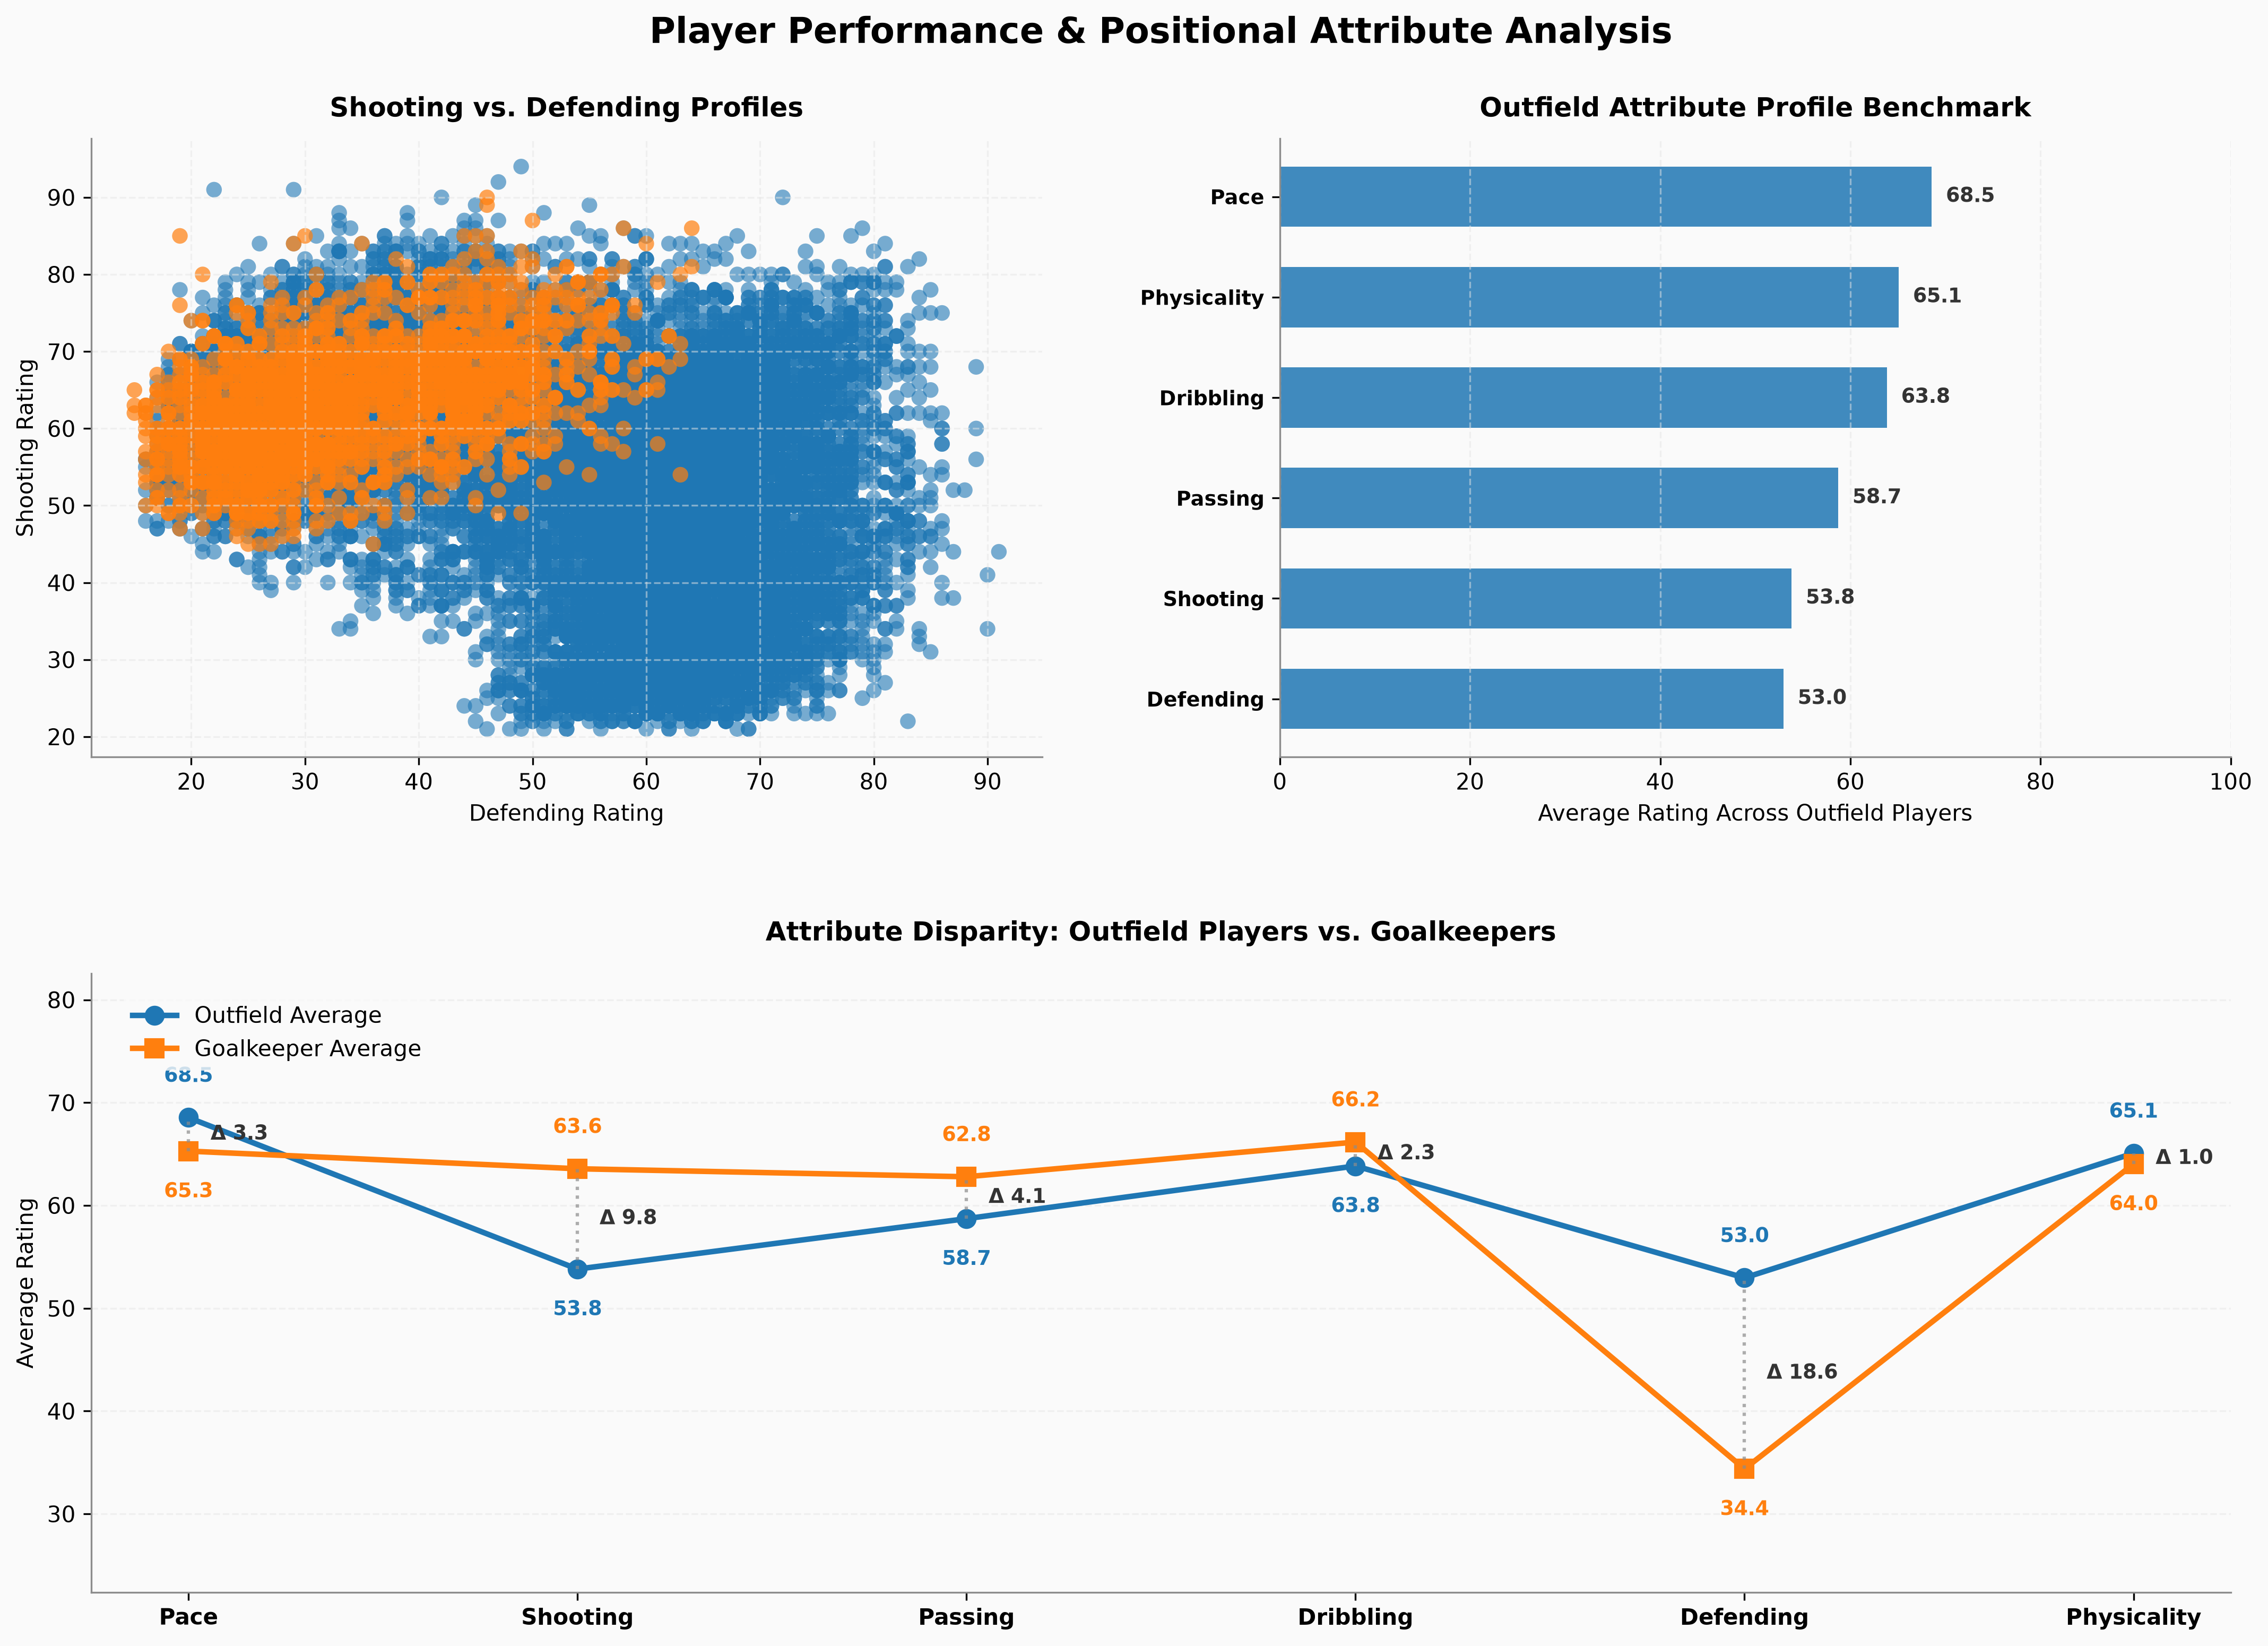

In [10]:
fig = plt.figure(figsize=(16, 11), dpi=300)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.35, wspace=0.25)

ax_top_left = fig.add_subplot(gs[0, 0])
ax_top_right = fig.add_subplot(gs[0, 1])
ax_bottom = fig.add_subplot(gs[1, :])

COLOR_OUTFIELD = "#1F77B4"
COLOR_GK = "#FF7F0E"
COLOR_MUTED = "#8C8C8C"
COLOR_BG = "#FAFAFA"
COLOR_GRID = "#E5E5E5"

fig.patch.set_facecolor(COLOR_BG)
for ax in [ax_top_left, ax_top_right, ax_bottom]:
    ax.set_facecolor(COLOR_BG)

metrics = ["pace", "shooting", "passing", "dribbling", "defending", "physicality"]

gk_subset = df[df["position"] == "GK"]
outfield_subset = df[df["position"] != "GK"]

ax_top_left.scatter(
    outfield_subset["defending"],
    outfield_subset["shooting"],
    c=COLOR_OUTFIELD,
    alpha=0.6,
    s=50,
    edgecolors="none",
    label="Outfield Players",
)
ax_top_left.scatter(
    gk_subset["defending"],
    gk_subset["shooting"],
    c=COLOR_GK,
    alpha=0.7,
    s=50,
    edgecolors="none",
    label="Goalkeepers",
)

ax_top_left.set_title(
    "Shooting vs. Defending Profiles", fontsize=12, fontweight="bold", pad=10
)
ax_top_left.set_xlabel("Defending Rating", fontsize=10)
ax_top_left.set_ylabel("Shooting Rating", fontsize=10)
ax_top_left.grid(True, linestyle="--", alpha=0.5, color=COLOR_GRID)
ax_top_left.spines["top"].set_visible(False)
ax_top_left.spines["right"].set_visible(False)
ax_top_left.spines["left"].set_color(COLOR_MUTED)
ax_top_left.spines["bottom"].set_color(COLOR_MUTED)

attribute_means = outfield_subset[metrics].mean().sort_values(ascending=True)
y_pos = range(len(attribute_means))

ax_top_right.barh(
    y_pos,
    attribute_means.values,
    color=COLOR_OUTFIELD,
    alpha=0.85,
    height=0.6,
)
ax_top_right.set_yticks(y_pos)
labels = [m.capitalize() for m in attribute_means.index]
ax_top_right.set_yticklabels(labels, fontsize=9, fontweight="bold")
ax_top_right.set_xlabel("Average Rating Across Outfield Players", fontsize=10)
ax_top_right.set_title(
    "Outfield Attribute Profile Benchmark", fontsize=12, fontweight="bold", pad=10
)
ax_top_right.set_xlim(0, 100)
ax_top_right.grid(True, axis="x", linestyle="--", alpha=0.5, color=COLOR_GRID)
ax_top_right.spines["top"].set_visible(False)
ax_top_right.spines["right"].set_visible(False)
ax_top_right.spines["left"].set_color(COLOR_MUTED)
ax_top_right.spines["bottom"].set_color(COLOR_MUTED)

for i, val in enumerate(attribute_means.values):
    ax_top_right.text(
        val + 1.5,
        i,
        f"{val:.1f}",
        va="center",
        color="#333333",
        fontweight="bold",
        fontsize=9,
    )

mean_outfield = outfield_subset[metrics].mean()
mean_gk = gk_subset[metrics].mean()

x_indices = np.arange(len(metrics))

ax_bottom.plot(
    x_indices,
    mean_outfield.values,
    color=COLOR_OUTFIELD,
    marker="o",
    linewidth=2.5,
    markersize=8,
    label="Outfield Average",
)
ax_bottom.plot(
    x_indices,
    mean_gk.values,
    color=COLOR_GK,
    marker="s",
    linewidth=2.5,
    markersize=8,
    label="Goalkeeper Average",
)

all_vals = np.concatenate([mean_outfield.values, mean_gk.values])
y_min_val, y_max_val = np.min(all_vals), np.max(all_vals)
ax_bottom.set_ylim(y_min_val - 12, y_max_val + 14)

for idx, (m_val, g_val) in enumerate(zip(mean_outfield.values, mean_gk.values)):
    ax_bottom.vlines(
        x=idx,
        ymin=min(m_val, g_val),
        ymax=max(m_val, g_val),
        color=COLOR_MUTED,
        linestyle=":",
        alpha=0.7,
        linewidth=1.5,
    )
    diff = abs(m_val - g_val)
    mid_y = (m_val + g_val) / 2
    ax_bottom.annotate(
        f"Δ {diff:.1f}",
        xy=(idx, mid_y),
        xytext=(10, 0),
        textcoords="offset points",
        fontsize=9,
        color="#333333",
        va="center",
        fontweight="semibold",
    )

    top_val, top_color = (m_val, COLOR_OUTFIELD) if m_val >= g_val else (g_val, COLOR_GK)
    bot_val, bot_color = (g_val, COLOR_GK) if m_val >= g_val else (m_val, COLOR_OUTFIELD)

    ax_bottom.text(
        idx,
        top_val + 3.0,
        f"{top_val:.1f}",
        ha="center",
        va="bottom",
        color=top_color,
        fontweight="bold",
        fontsize=9,
    )
    ax_bottom.text(
        idx,
        bot_val - 3.0,
        f"{bot_val:.1f}",
        ha="center",
        va="top",
        color=bot_color,
        fontweight="bold",
        fontsize=9,
    )

ax_bottom.set_xticks(x_indices)
ax_bottom.set_xticklabels(
    [m.capitalize() for m in metrics], fontsize=10, fontweight="bold"
)
ax_bottom.set_ylabel("Average Rating", fontsize=10)
ax_bottom.set_title(
    "Attribute Disparity: Outfield Players vs. Goalkeepers",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
ax_bottom.legend(
    loc="upper left",
    bbox_to_anchor=(0.01, 0.98),
    frameon=True,
    facecolor=COLOR_BG,
    edgecolor="none",
    fontsize=10,
)
ax_bottom.grid(True, axis="y", linestyle="--", alpha=0.5, color=COLOR_GRID)
ax_bottom.spines["top"].set_visible(False)
ax_bottom.spines["right"].set_visible(False)
ax_bottom.spines["left"].set_color(COLOR_MUTED)
ax_bottom.spines["bottom"].set_color(COLOR_MUTED)

fig.suptitle(
    "Player Performance & Positional Attribute Analysis",
    fontsize=16,
    fontweight="bold",
    y=0.98,
)

fig.subplots_adjust(top=0.91, bottom=0.08, left=0.08, right=0.92)

### 2. Distribution of the `overall_rating`

In [11]:
mean_val = df["overall_rating"].mean()
median_val = df["overall_rating"].median()
std_val = df["overall_rating"].std()

p90_val = df["overall_rating"].quantile(0.90)
p99_val = df["overall_rating"].quantile(0.99)

skew_val = df["overall_rating"].skew()
kurt_val = df["overall_rating"].kurtosis()

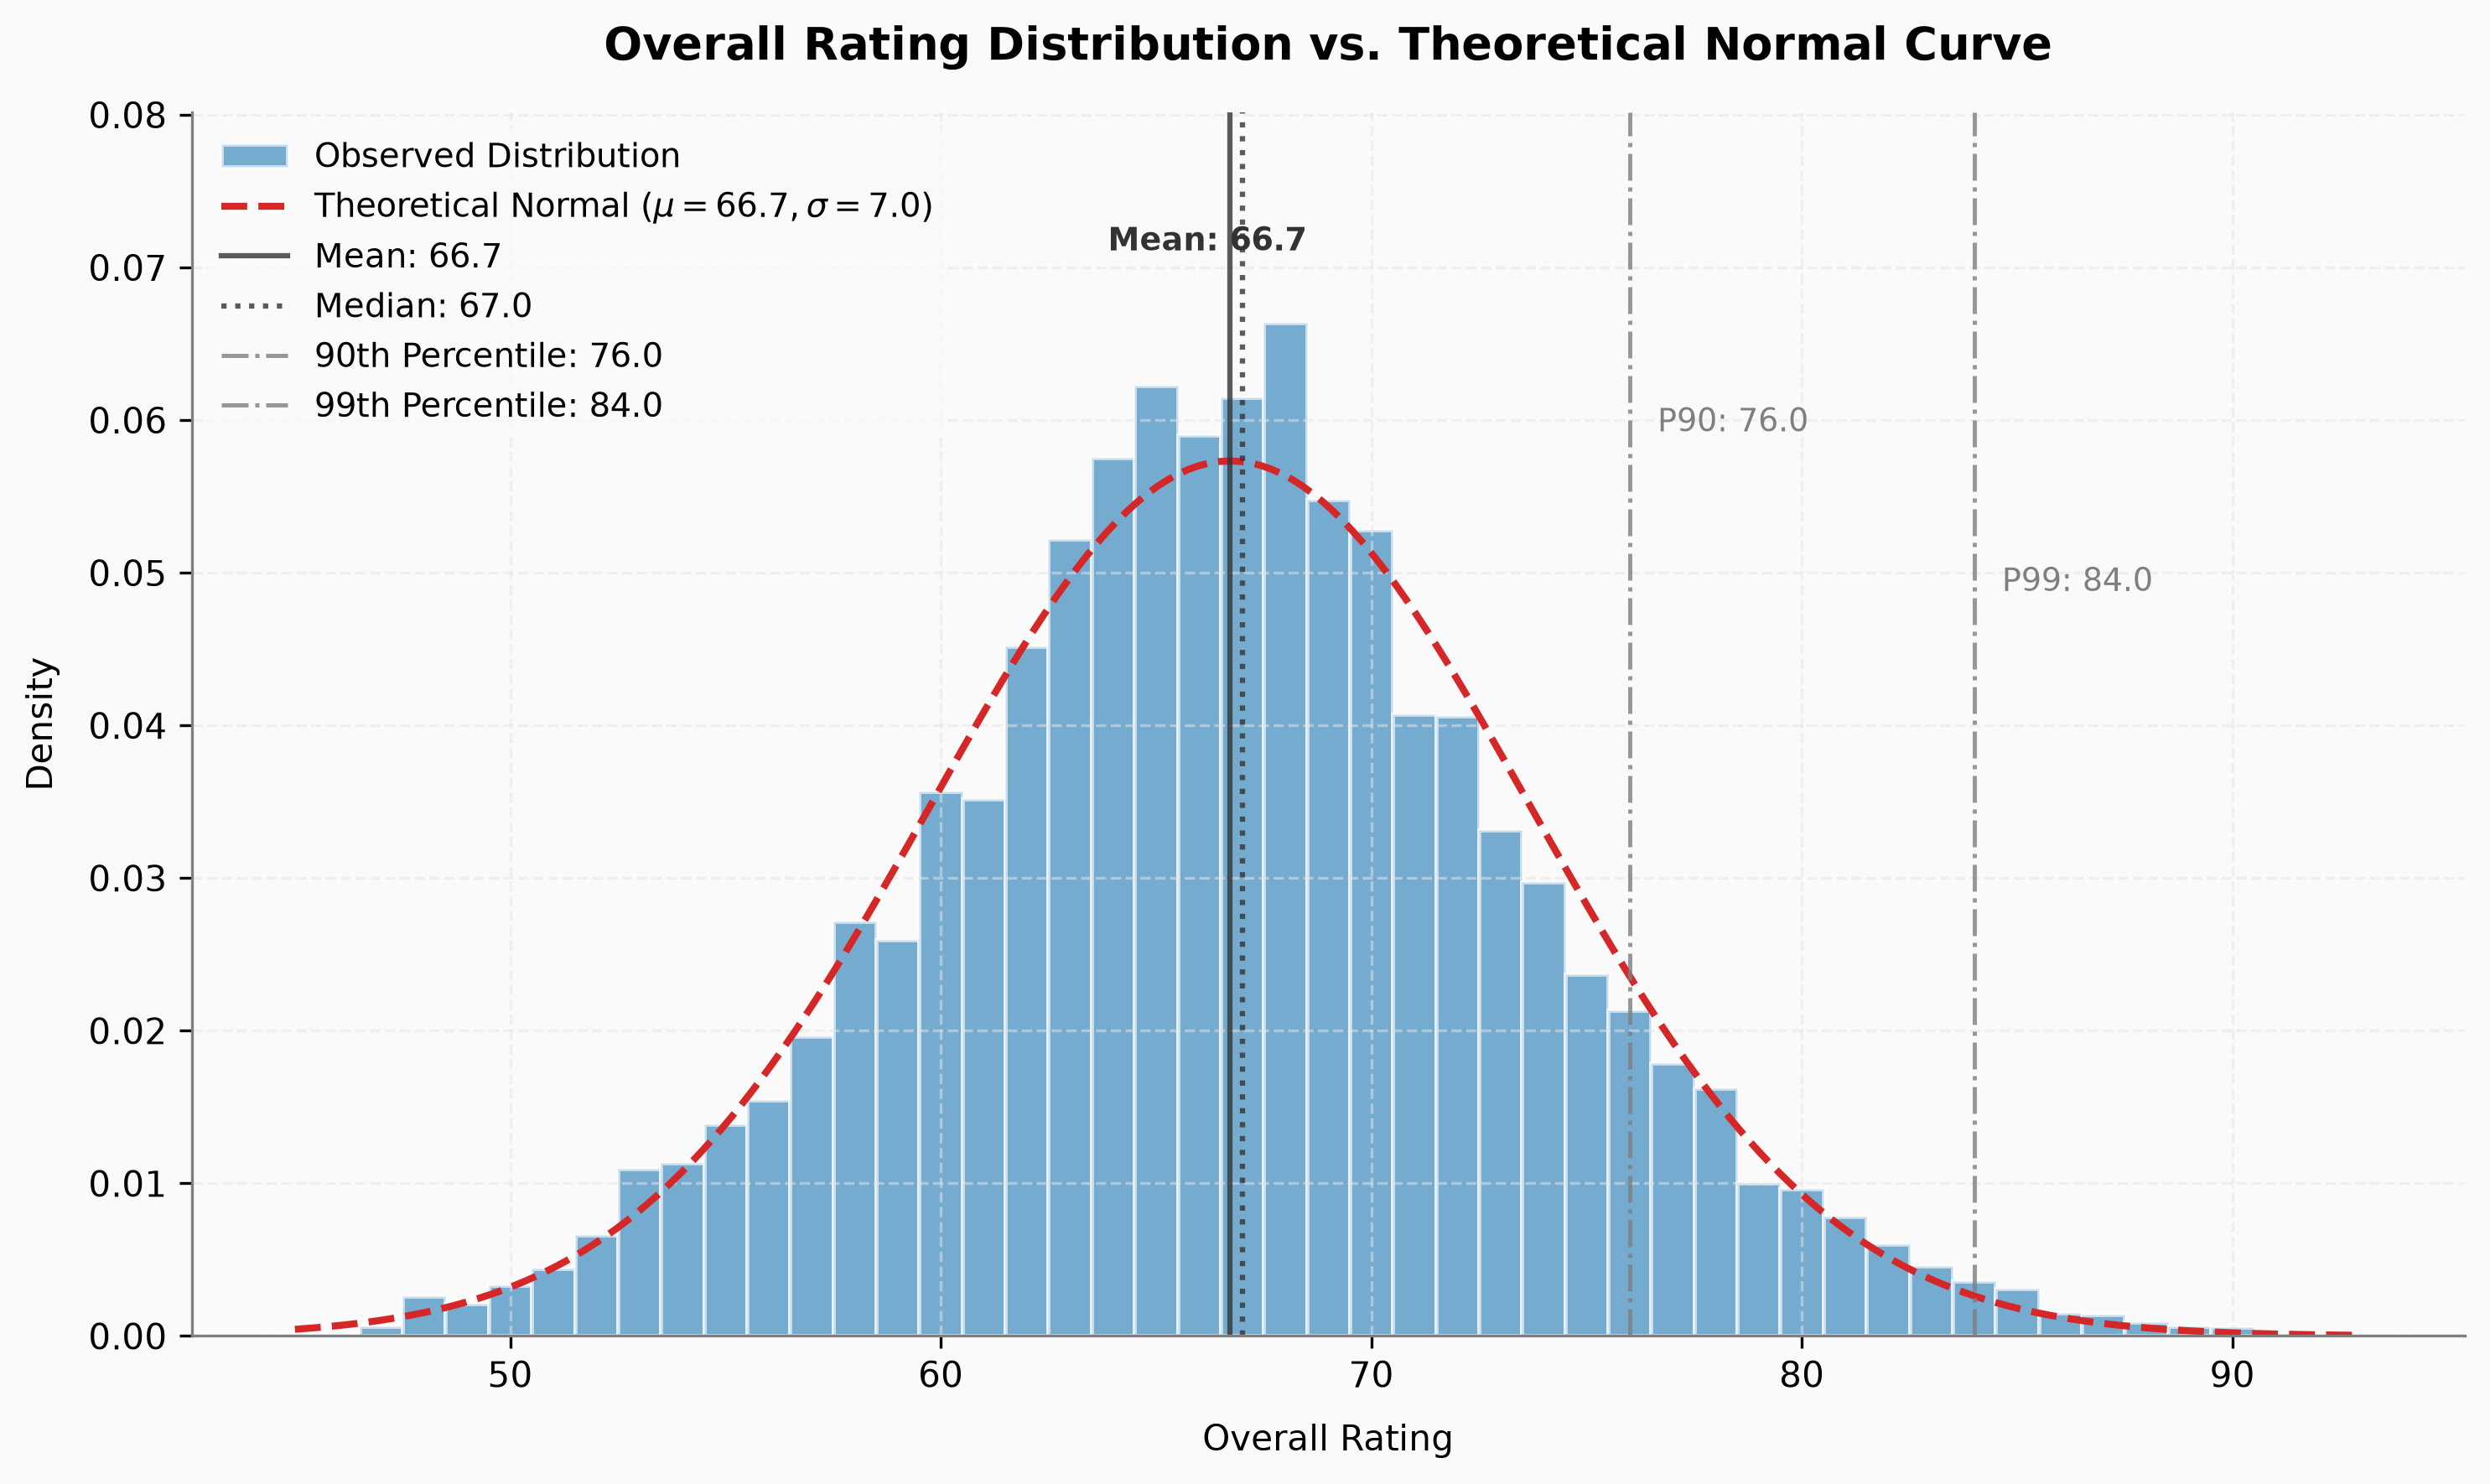

In [12]:
fig, ax = plt.subplots(figsize=(10, 6), dpi=300)

COLOR_MAIN = "#1F77B4"
COLOR_ACCENT = "#D62728"
COLOR_MUTED = "#7F7F7F"
COLOR_BG = "#FAFAFA"
COLOR_GRID = "#E5E5E5"

fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_BG)

ratings = df["overall_rating"].dropna()

mean_val = ratings.mean()
median_val = ratings.median()
std_val = ratings.std()
p90_val = ratings.quantile(0.90)
p99_val = ratings.quantile(0.99)

bins = np.arange(ratings.min() - 0.5, ratings.max() + 1.5, 1)

n, bins_out, patches = ax.hist(
    ratings,
    bins=bins,
    density=True,
    color=COLOR_MAIN,
    alpha=0.6,
    edgecolor="white",
    linewidth=1.2,
    label="Observed Distribution",
)

x_norm = np.linspace(ratings.min() - 2, ratings.max() + 2, 200)
y_norm = (1 / (std_val * np.sqrt(2 * np.pi))) * np.exp(
    -0.5 * ((x_norm - mean_val) / std_val) ** 2
)
ax.plot(
    x_norm,
    y_norm,
    color=COLOR_ACCENT,
    linewidth=2,
    linestyle="--",
    label=rf"Theoretical Normal ($\mu={mean_val:.1f}, \sigma={std_val:.1f}$)",
)

ax.axvline(
    mean_val,
    color="#333333",
    linestyle="-",
    linewidth=1.5,
    alpha=0.8,
    label=f"Mean: {mean_val:.1f}",
)
ax.axvline(
    median_val,
    color="#333333",
    linestyle=":",
    linewidth=1.5,
    alpha=0.8,
    label=f"Median: {median_val:.1f}",
)
ax.axvline(
    p90_val,
    color=COLOR_MUTED,
    linestyle="-.",
    linewidth=1.2,
    alpha=0.8,
    label=f"90th Percentile: {p90_val:.1f}",
)
ax.axvline(
    p99_val,
    color=COLOR_MUTED,
    linestyle="-.",
    linewidth=1.2,
    alpha=0.8,
    label=f"99th Percentile: {p99_val:.1f}",
)

y_max = ax.get_ylim()[1]
ax.set_ylim(0, y_max * 1.15)

ax.annotate(
    f"Mean: {mean_val:.1f}",
    xy=(mean_val, y_max * 1.02),
    xytext=(-35, 0),
    textcoords="offset points",
    fontsize=9,
    fontweight="semibold",
    color="#333333",
)

ax.annotate(
    f"P90: {p90_val:.1f}",
    xy=(p90_val, y_max * 0.85),
    xytext=(8, 0),
    textcoords="offset points",
    fontsize=9,
    color=COLOR_MUTED,
)

ax.annotate(
    f"P99: {p99_val:.1f}",
    xy=(p99_val, y_max * 0.70),
    xytext=(8, 0),
    textcoords="offset points",
    fontsize=9,
    color=COLOR_MUTED,
)

ax.set_title(
    "Overall Rating Distribution vs. Theoretical Normal Curve",
    fontsize=13,
    fontweight="bold",
    pad=15,
)
ax.set_xlabel("Overall Rating", fontsize=10, labelpad=8)
ax.set_ylabel("Density", fontsize=10, labelpad=8)

ax.grid(True, linestyle="--", alpha=0.5, color=COLOR_GRID)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(COLOR_MUTED)
ax.spines["bottom"].set_color(COLOR_MUTED)

ax.legend(
    loc="upper left",
    frameon=True,
    facecolor=COLOR_BG,
    edgecolor="none",
    fontsize=9.5,
)

fig.tight_layout()

### 3. Playstyle Analysis

In [13]:
df["playstyles"].value_counts()

playstyles
Technical                                                     347
Rapid                                                         311
Aerial Fortress                                               288
Long Ball Pass                                                212
Intercept                                                     176
                                                             ... 
Finesse Shot, Dead Ball, Whipped Pass, Bruiser                  1
Whipped Pass, Aerial Fortress, Long Throw                       1
Incisive Pass, Long Ball Pass, Slide Tackle                     1
Finesse Shot, Low Driven Shot, Long Throw                       1
Precision Header, Acrobatic, Low Driven Shot, Press Proven      1
Name: count, Length: 1930, dtype: int64

In [14]:
style_frequency: dict[str, int] = dict()
playstyles_series = df["playstyles"].fillna("undefined")

for style_sequence in playstyles_series:
    styles = [s.strip() for s in style_sequence.split(",")]
    for style in styles:
        style_frequency[style] = style_frequency.get(style, 0) + 1
        
del style_frequency["undefined"]

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


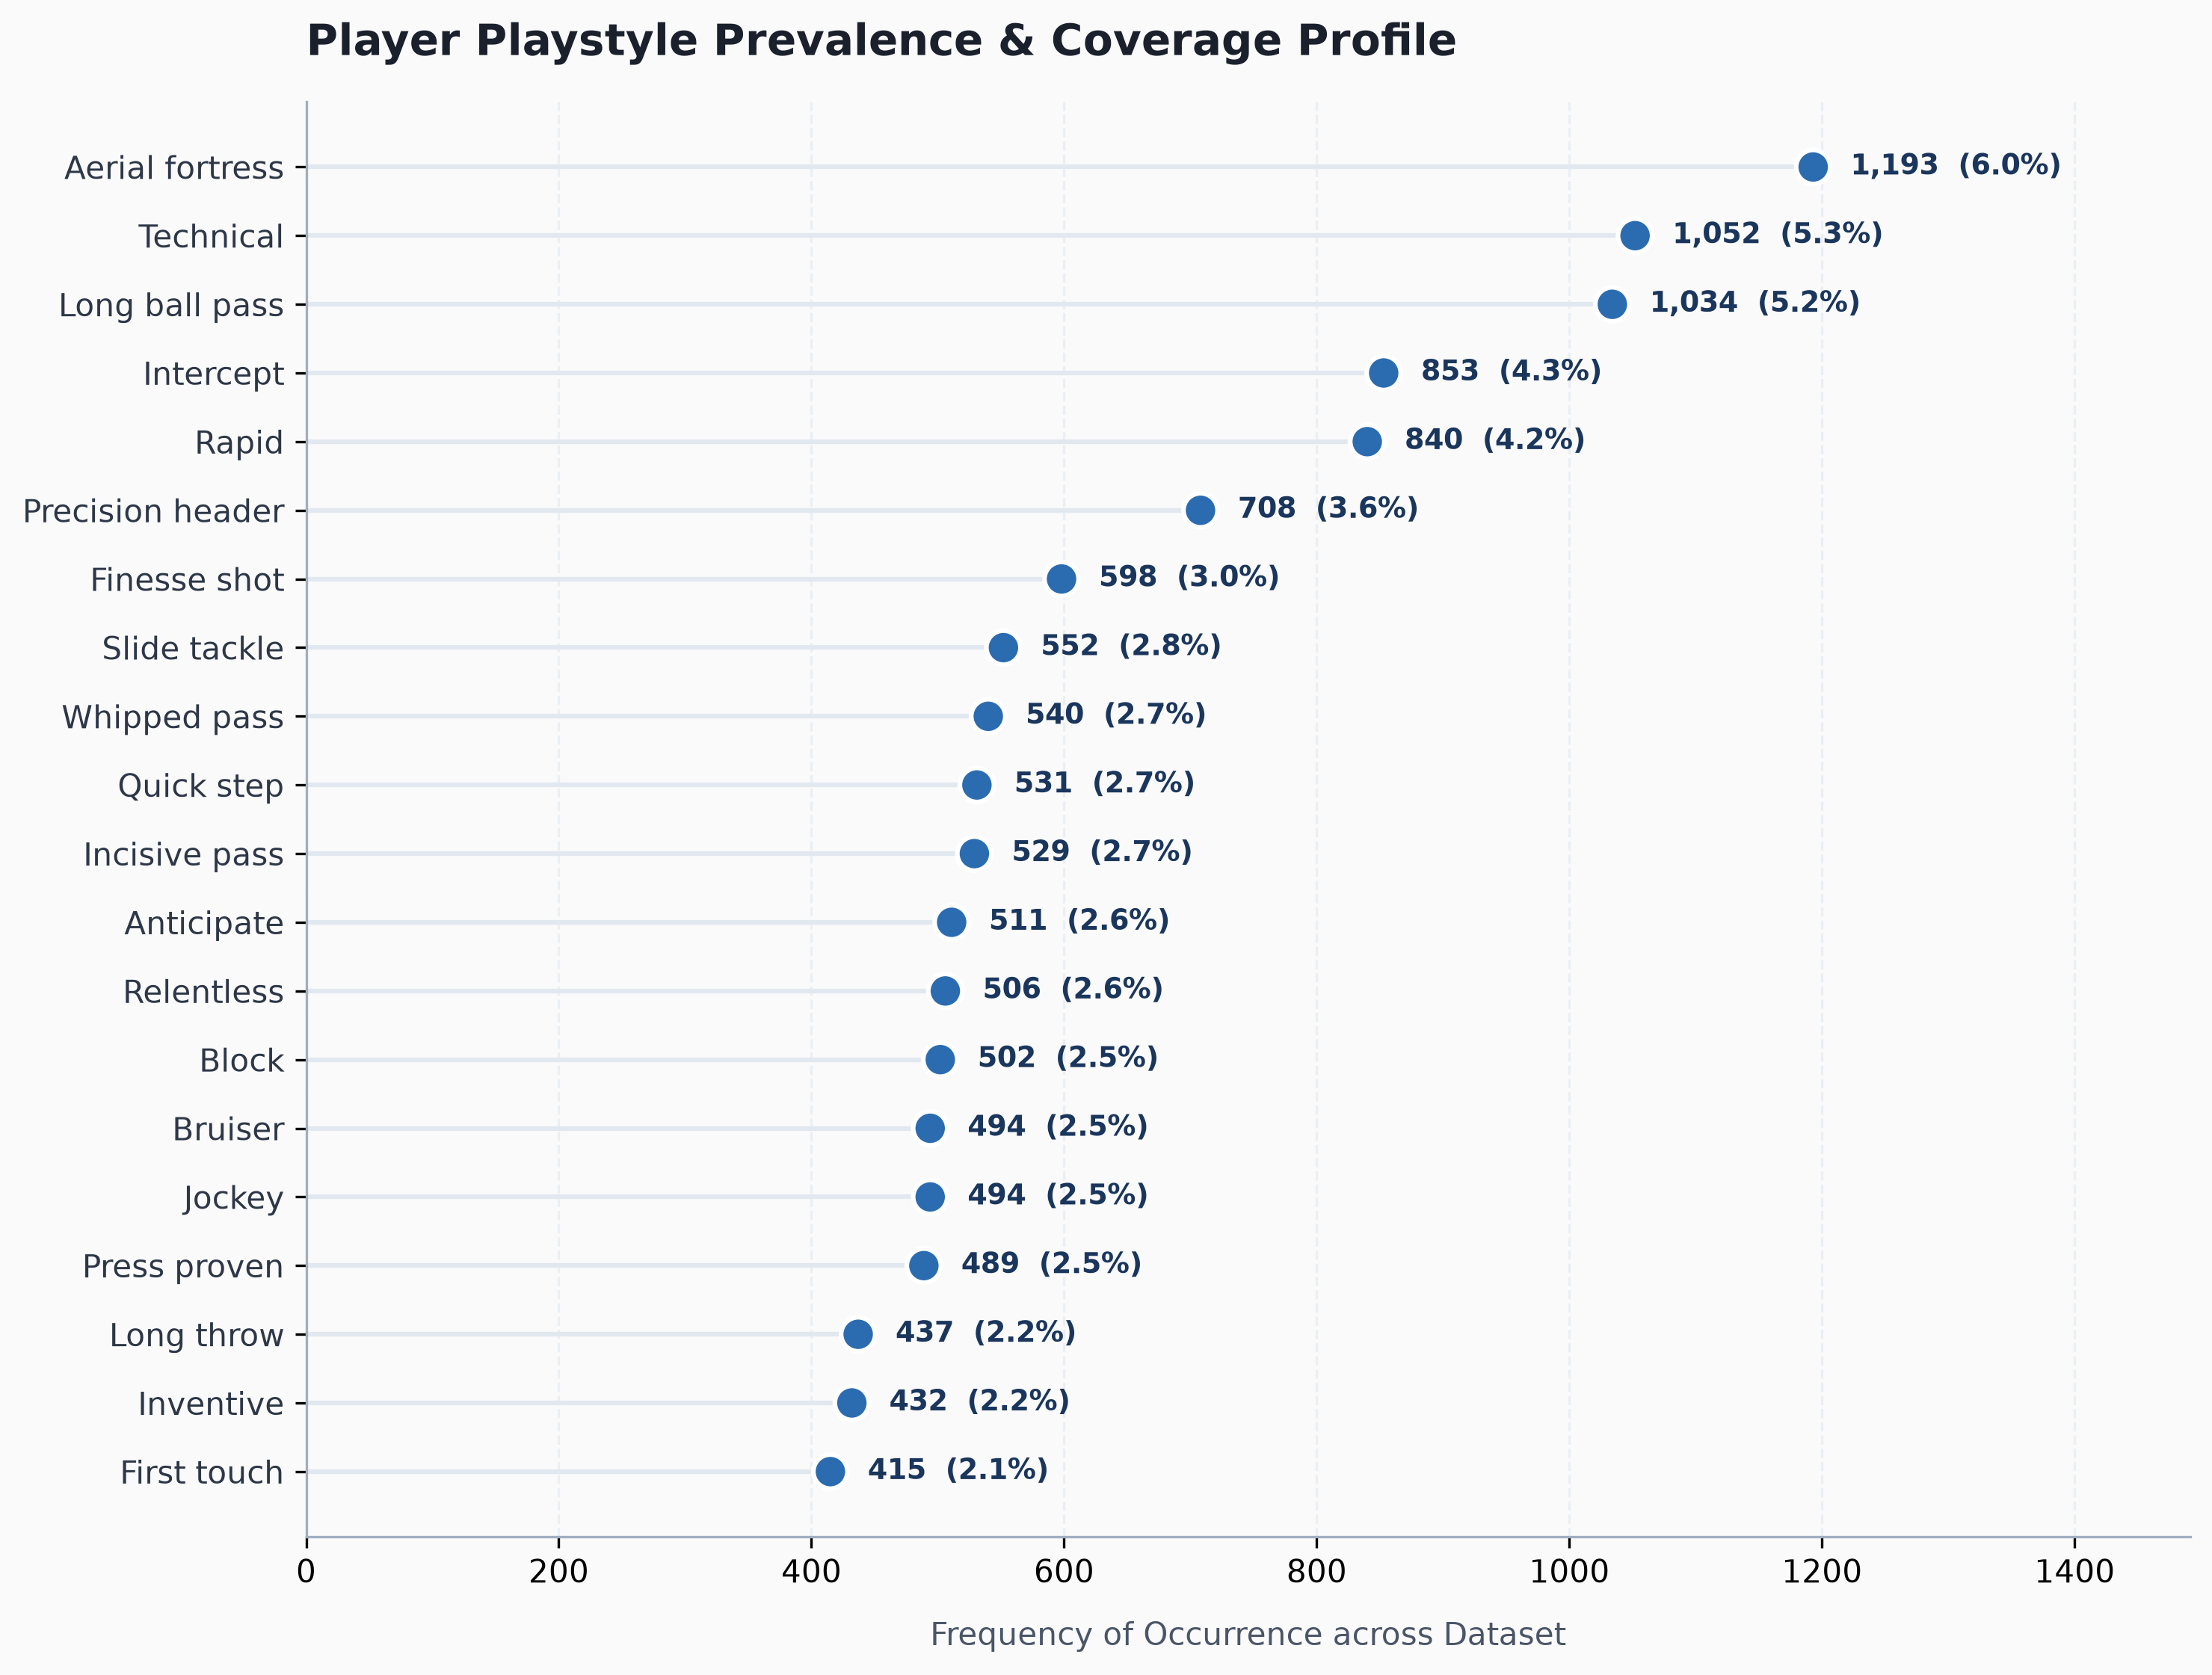

In [15]:
sorted_styles = sorted(style_frequency.items(), key=lambda x: x[1], reverse=True)[: 20]
labels = [item[0].capitalize() for item in sorted_styles]
values = [item[1] for item in sorted_styles]
total_players = len(df)
percentages = [(v / total_players) * 100 for v in values]

fig, ax = plt.subplots(figsize=(12, 8), dpi=300)

COLOR_PRIMARY = "#1A365D"
COLOR_ACCENT = "#2B6CB0"
COLOR_HIGHLIGHT = "#C53030"
COLOR_MUTED = "#A0AEC0"
COLOR_BG = "#FAFAFA"
COLOR_GRID = "#E2E8F0"

fig.patch.set_facecolor(COLOR_BG)
ax.set_facecolor(COLOR_BG)

y_positions = np.arange(len(labels))

colors = [
    COLOR_HIGHLIGHT if label.lower() == "undefined" else COLOR_ACCENT
    for label in labels
]

ax.hlines(
    y=y_positions,
    xmin=0,
    xmax=values,
    color=COLOR_GRID,
    linewidth=1.5,
    zorder=1,
)

ax.scatter(
    values,
    y_positions,
    c=colors,
    s=120,
    zorder=2,
    edgecolors="white",
    linewidth=1.5,
)

max_val = max(values) if values else 1
ax.set_xlim(0, max_val * 1.25)

for i, (val, pct) in enumerate(zip(values, percentages)):
    color = COLOR_HIGHLIGHT if labels[i].lower() == "undefined" else COLOR_PRIMARY
    ax.annotate(
        f"{val:,}  ({pct:.1f}%)",
        xy=(val, i),
        xytext=(12, 0),
        textcoords="offset points",
        va="center",
        ha="left",
        fontsize=9,
        fontweight="semibold",
        color=color,
    )

ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=10, fontweight="medium", color="#2D3748")
ax.invert_yaxis()

ax.set_xlabel("Frequency of Occurrence across Dataset", fontsize=10, labelpad=10, color="#4A5568")
ax.set_title(
    "Player Playstyle Prevalence & Coverage Profile",
    fontsize=14,
    fontweight="bold",
    pad=15,
    color="#1A202C",
    loc="left",
)

ax.grid(True, axis="x", linestyle="--", alpha=0.6, color=COLOR_GRID)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color(COLOR_MUTED)
ax.spines["bottom"].set_color(COLOR_MUTED)

fig.subplots_adjust(left=0.22, right=0.92, top=0.90, bottom=0.10)

### 4. Dividing Players by their Age and Analysis of it

In [16]:
divided_df = df[["first_name", "last_name", "position", "overall_rating", "birthdate", "pace"]].copy()

divided_df["age"] = (
    (pd.Timestamp.now() - pd.to_datetime(divided_df["birthdate"])) 
    / pd.Timedelta(days=365.25)
).astype(int)

divided_df = divided_df.drop(columns="birthdate")

In [17]:
divided_df["age_group"] = pd.qcut(
    divided_df["age"],
    q=3,
    labels=["Young", "Prime", "Veteran"],
    duplicates='drop',
)

divided_df.head()

,first_name,last_name,position,overall_rating,pace,age,age_group
0,Alexia,Putellas Segura,CM,91,80,32,Veteran
1,Kylian,Mbappé,ST,91,96,27,Prime
2,Erling,Haaland,ST,91,87,26,Prime
3,Thibaut,Courtois,GK,90,87,34,Veteran
4,Harry,Kane,ST,90,62,33,Veteran


In [18]:
age_group_aggregated = (
    divided_df
    .groupby(by="age_group")
    .agg(
        avg_rating=("overall_rating", "mean"),
        avg_pace=("pace", "mean")
    )
    .reset_index()
)

age_group_aggregated

,age_group,avg_rating,avg_pace
0,Young,63.240126,67.592336
1,Prime,68.258248,70.263603
2,Veteran,69.516210,66.994177


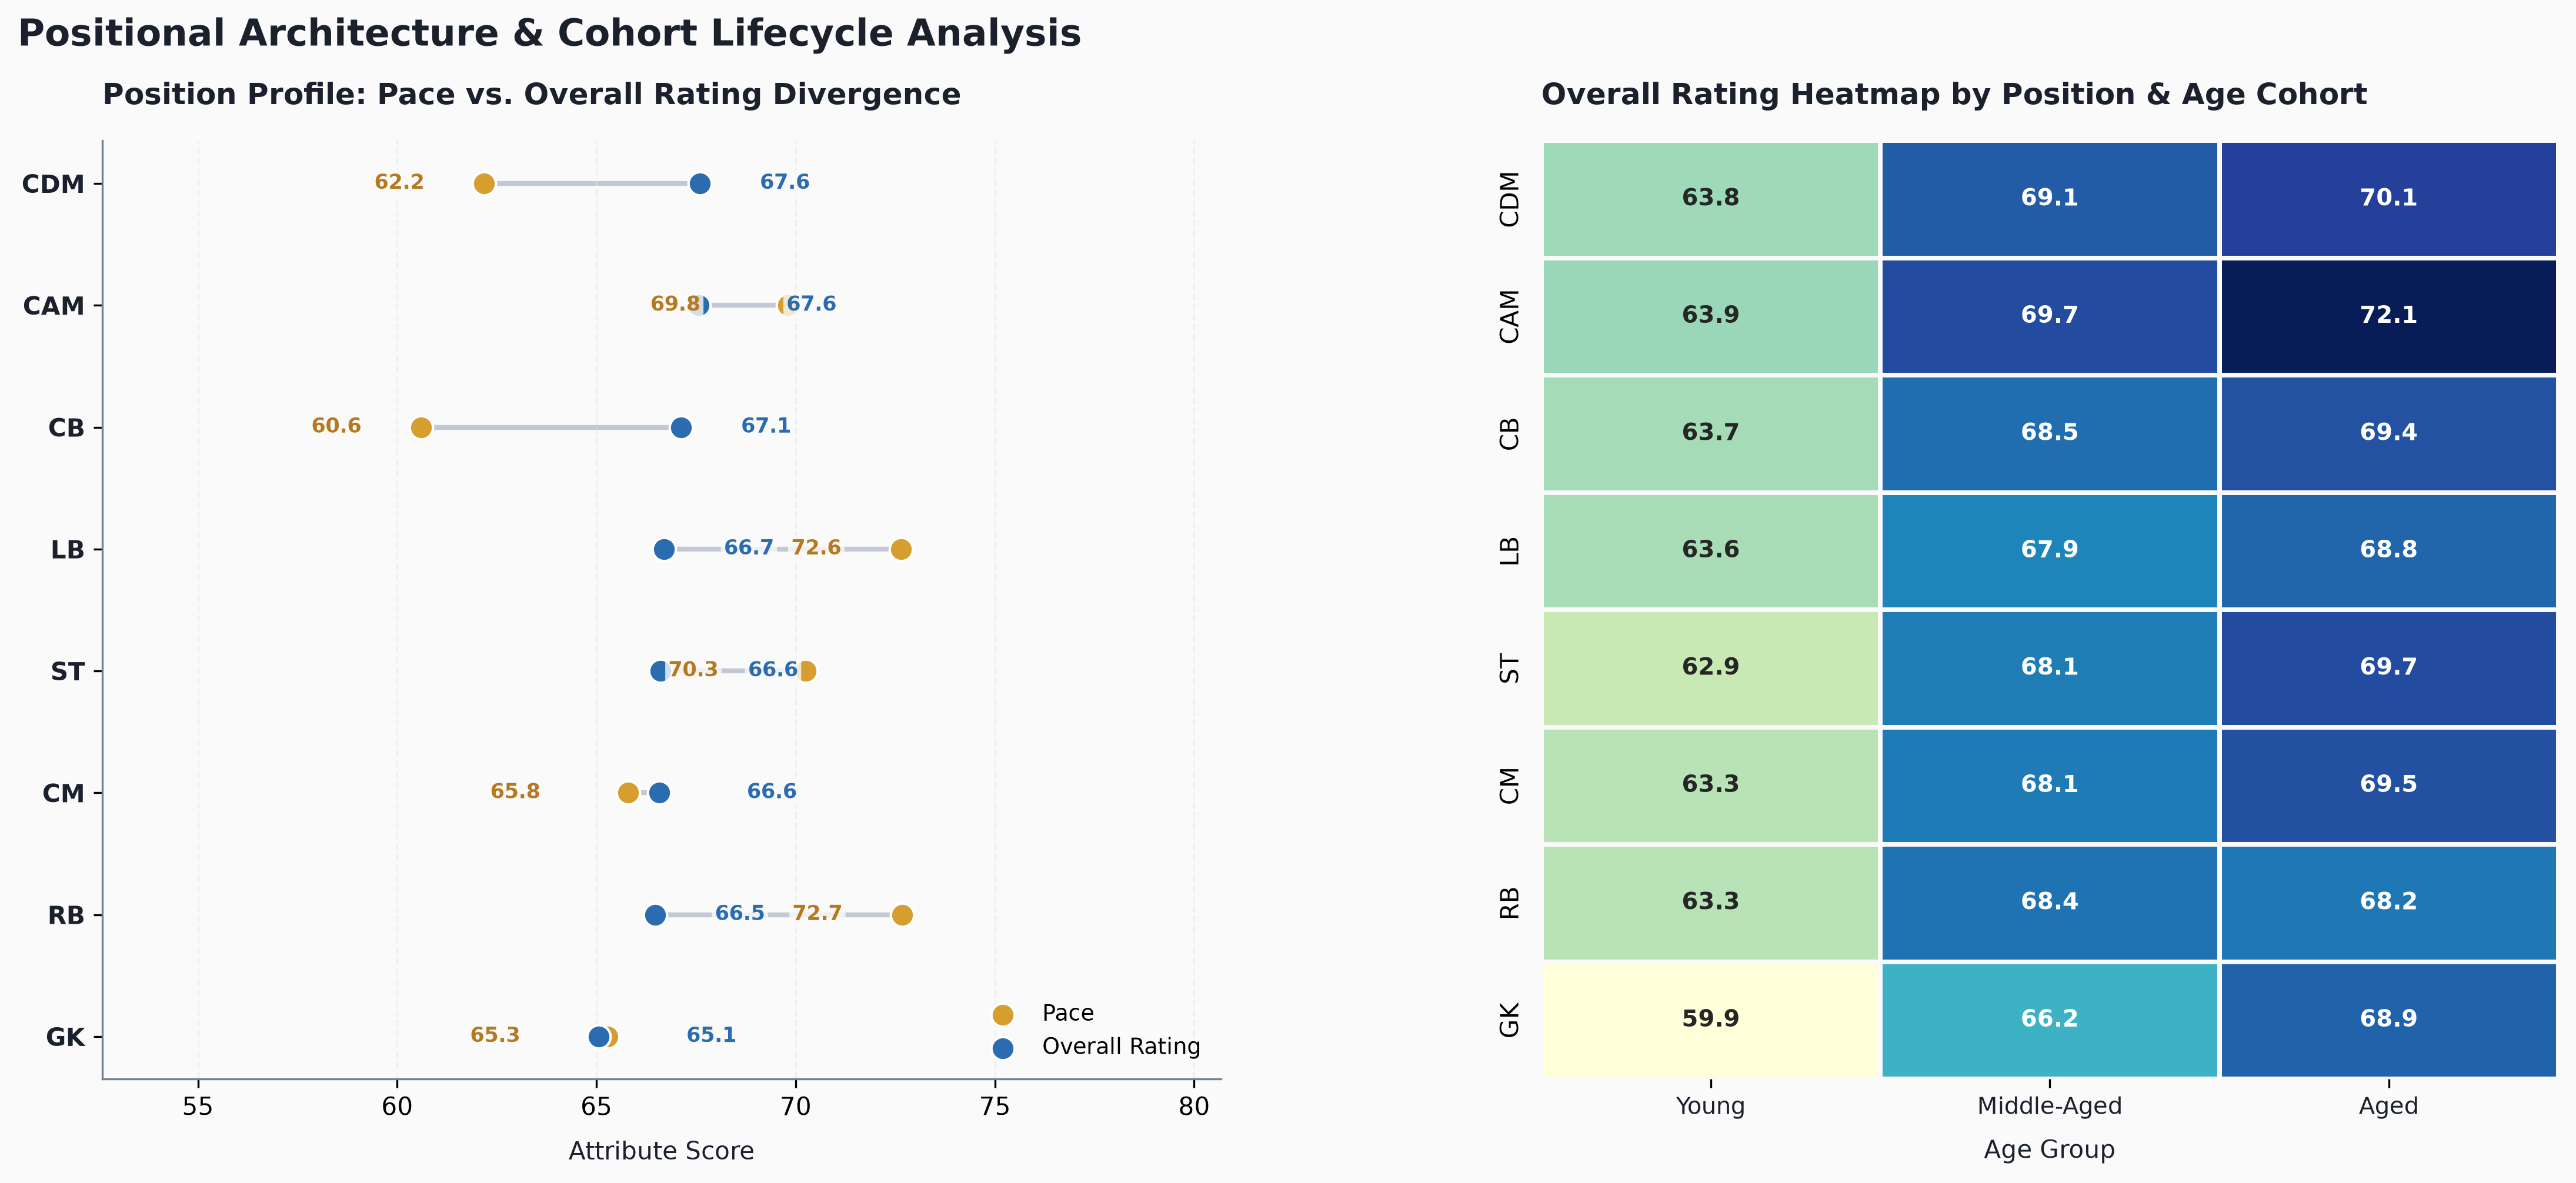

In [19]:
plot_df = divided_df.copy(deep=True)

COLOR_YOUNG = "#2B6CB0"
COLOR_PRIME = "#2F855A"
COLOR_VETERAN = "#C53030"
COLOR_BG = "#FAFAFA"
COLOR_GRID = "#E2E8F0"
COLOR_MUTED = "#718096"
COLOR_TEXT = "#1A202C"

palette = {
    "young": COLOR_YOUNG,
    "middle_aged": COLOR_PRIME,
    "aged": COLOR_VETERAN,
}

top_positions = plot_df["position"].value_counts().nlargest(8).index
filtered_df = plot_df[plot_df["position"].isin(top_positions)].copy()

position_metrics = (
    filtered_df.groupby("position")
    .agg(
        avg_overall=("overall_rating", "mean"),
        avg_pace=("pace", "mean"),
        avg_age=("age", "mean"),
        count=("overall_rating", "count"),
    )
    .reset_index()
    .sort_values(by="avg_overall", ascending=False)
)

fig, (ax1, ax2) = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 7),
    dpi=300,
    gridspec_kw={"width_ratios": [1.1, 1]},
)

fig.patch.set_facecolor(COLOR_BG)
ax1.set_facecolor(COLOR_BG)
ax2.set_facecolor(COLOR_BG)

positions = position_metrics["position"]
y_pos = np.arange(len(positions))

min_val = min(position_metrics["avg_pace"].min(), position_metrics["avg_overall"].min())
max_val = max(position_metrics["avg_pace"].max(), position_metrics["avg_overall"].max())
ax1.set_xlim(min_val - 8, max_val + 8)

ax1.hlines(
    y=y_pos,
    xmin=position_metrics["avg_pace"],
    xmax=position_metrics["avg_overall"],
    color=COLOR_MUTED,
    alpha=0.4,
    linewidth=2,
    zorder=1,
)

ax1.scatter(
    position_metrics["avg_pace"],
    y_pos,
    color="#D69E2E",
    s=90,
    label="Pace",
    zorder=2,
    edgecolor="white",
    linewidth=1,
)

ax1.scatter(
    position_metrics["avg_overall"],
    y_pos,
    color=COLOR_YOUNG,
    s=90,
    label="Overall Rating",
    zorder=2,
    edgecolor="white",
    linewidth=1,
)

for idx, row in position_metrics.reset_index(drop=True).iterrows():
    pace_val = row["avg_pace"]
    overall_val = row["avg_overall"]

    if abs(pace_val - overall_val) < 4:
        pace_offset = -2.2
        overall_offset = 2.2
    else:
        pace_offset = -1.5
        overall_offset = 1.5

    ax1.text(
        pace_val + pace_offset,
        idx,
        f"{pace_val:.1f}",
        va="center",
        ha="right" if pace_offset < 0 else "left",
        fontsize=8.5,
        fontweight="bold",
        color="#B7791F",
        bbox=dict(boxstyle="round,pad=0.15", facecolor=COLOR_BG, edgecolor="none", alpha=0.8),
    )

    ax1.text(
        overall_val + overall_offset,
        idx,
        f"{overall_val:.1f}",
        va="center",
        ha="left" if overall_offset > 0 else "right",
        fontsize=8.5,
        fontweight="bold",
        color=COLOR_YOUNG,
        bbox=dict(boxstyle="round,pad=0.15", facecolor=COLOR_BG, edgecolor="none", alpha=0.8),
    )

ax1.set_yticks(y_pos)
ax1.set_yticklabels(positions, fontsize=10, fontweight="bold", color=COLOR_TEXT)
ax1.invert_yaxis()
ax1.set_title(
    "Position Profile: Pace vs. Overall Rating Divergence",
    fontsize=12,
    fontweight="bold",
    color=COLOR_TEXT,
    pad=15,
    loc="left",
)
ax1.set_xlabel("Attribute Score", fontsize=10, color=COLOR_TEXT, labelpad=8)
ax1.grid(True, axis="x", linestyle="--", alpha=0.5, color=COLOR_GRID)
ax1.legend(loc="lower right", frameon=False, fontsize=9)

heatmap_data = (
    filtered_df.groupby(["position", "age_group"], observed=False)["overall_rating"]
    .mean()
    .unstack()
    .reindex(positions)
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar=False,
    linewidths=1.5,
    linecolor=COLOR_BG,
    ax=ax2,
    annot_kws={"size": 9.5, "weight": "bold"},
)

ax2.set_title(
    "Overall Rating Heatmap by Position & Age Cohort",
    fontsize=12,
    fontweight="bold",
    color=COLOR_TEXT,
    pad=15,
    loc="left",
)
ax2.set_xlabel("Age Group", fontsize=10, color=COLOR_TEXT, labelpad=8)
ax2.set_ylabel("", fontsize=10)
ax2.set_xticklabels(
    ["Young", "Middle-Aged", "Aged"], fontsize=9.5, color=COLOR_TEXT
)
ax2.tick_params(axis="y", left=False)

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)
ax1.spines["left"].set_color(COLOR_MUTED)
ax1.spines["bottom"].set_color(COLOR_MUTED)

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.spines["left"].set_visible(False)
ax2.spines["bottom"].set_color(COLOR_MUTED)

fig.suptitle(
    "Positional Architecture & Cohort Lifecycle Analysis",
    fontsize=15,
    fontweight="bold",
    color=COLOR_TEXT,
    x=0.05,
    y=0.98,
    ha="left",
)

fig.subplots_adjust(left=0.08, right=0.95, top=0.88, bottom=0.12, wspace=0.3)

### 5. Men's Football and Women's Football

In [20]:
df.head()

,player_id,first_name,last_name,overall_rating,position,club,league,nationality,gender,preferred_foot,...,mentality_penalties,mentality_composure,defending_awareness,defending_standing_tackle,defending_sliding_tackle,goalkeeping_diving,goalkeeping_handling,goalkeeping_kicking,goalkeeping_positioning,goalkeeping_reflexes
0,227203,Alexia,Putellas Segura,91,CM,London City,Barclays WSL,Spain,Women's Football,Left,...,89,92,60,82,64,15,17,11,15,10
1,231747,Kylian,Mbappé,91,ST,Real Madrid,LALIGA EA SPORTS,France,Men's Football,Right,...,86,88,15,34,24,13,5,7,11,6
2,239085,Erling,Haaland,91,ST,Manchester City,Premier League,Norway,Men's Football,Left,...,89,86,42,47,33,7,14,13,11,7
3,192119,Thibaut,Courtois,90,GK,Real Madrid,LALIGA EA SPORTS,Belgium,Men's Football,Left,...,27,66,20,18,16,87,89,78,90,90
4,202126,Harry,Kane,90,ST,FC Bayern München,Bundesliga,England,Men's Football,Right,...,93,92,46,44,42,8,10,11,14,11


In [25]:
# The issue with following analysis is that men's and women's football are isolated from each other so
# ratings and stats are purely isolated. For instance, women player with 91 rating cannot play similarly
# to the man rated 91. So the only option is to compare distribution of rating and physicality. 

mens_football = df[df["gender"] == "Men's Football"]
womens_football = df[df["gender"] != "Men's Football"]

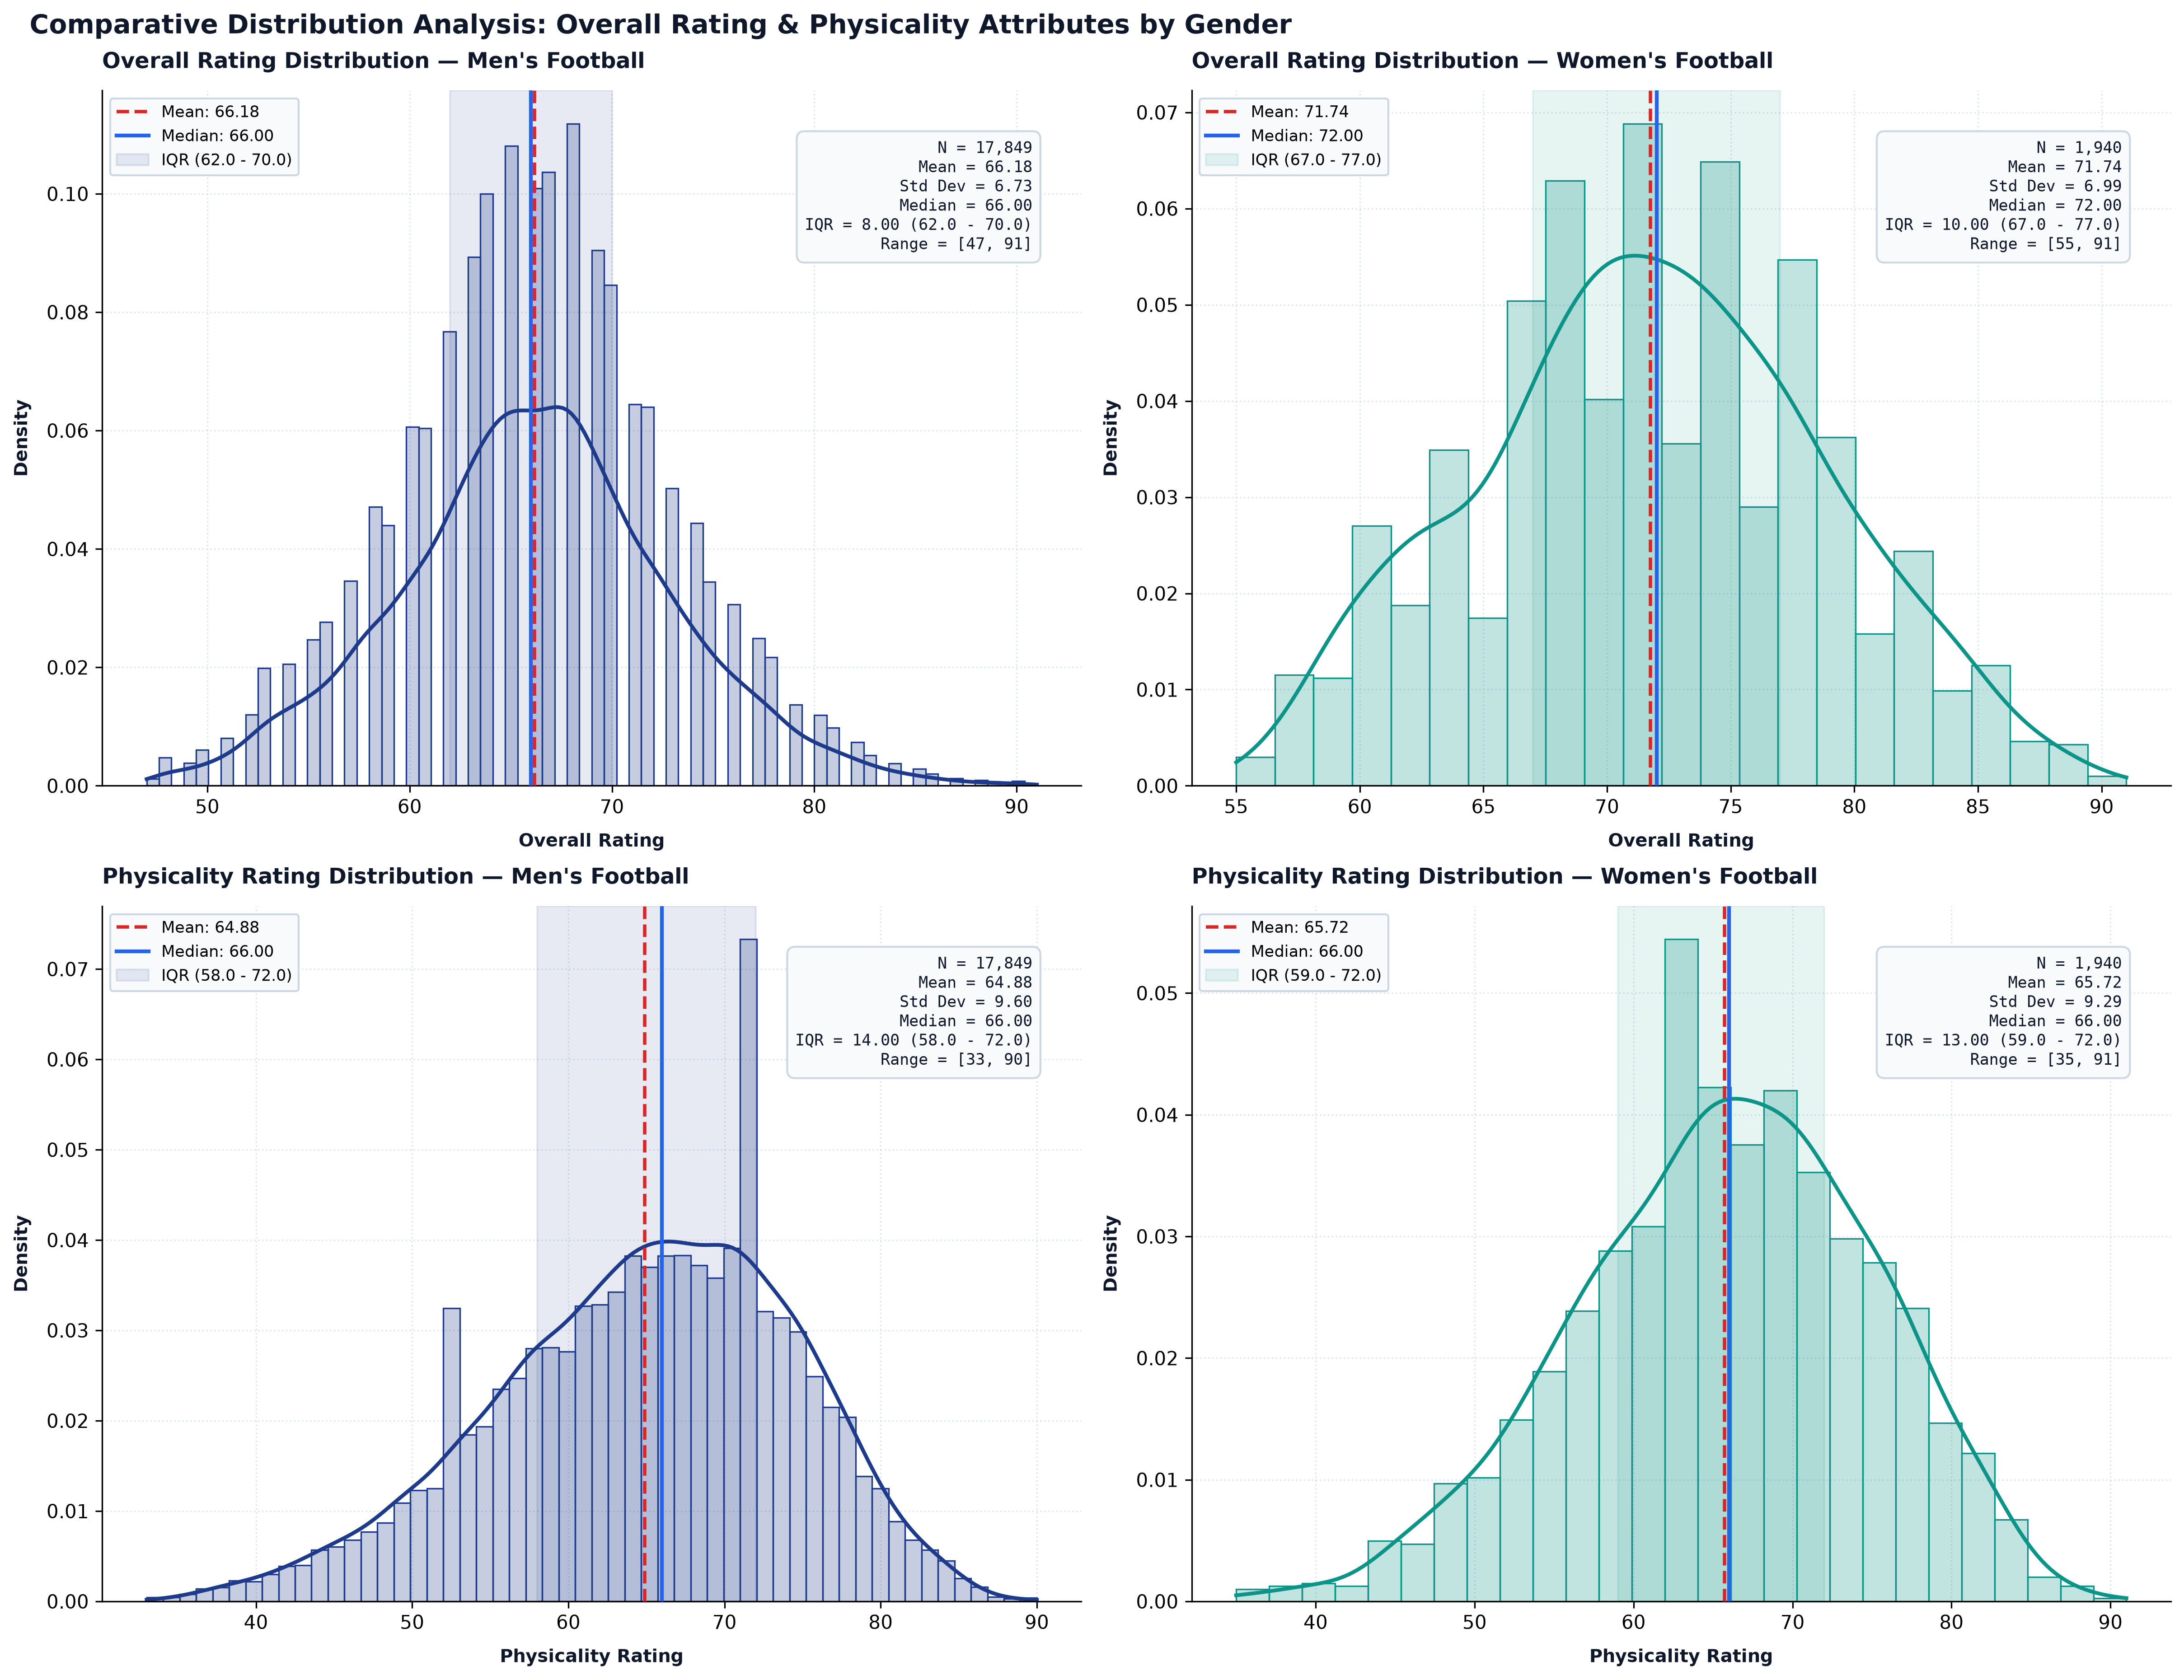

In [26]:
metrics = [
    {"col": "overall_rating", "title": "Overall Rating Distribution"},
    {"col": "physicality", "title": "Physicality Rating Distribution"},
]

genders = [
    {"label": "Men's Football", "key": "Men's Football", "color": "#1e3a8a"},
    {"label": "Women's Football", "key": "Women's Football", "color": "#0d9488"},
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12),
    dpi=300,
    layout="constrained",
    sharey=False,
)
fig.patch.set_facecolor("white")

for row_idx, metric in enumerate(metrics):
    col_name = metric["col"]

    for col_idx, gender_info in enumerate(genders):
        ax = axes[row_idx, col_idx]
        ax.set_facecolor("white")

        data = df[df["gender"] == gender_info["key"]][col_name].dropna()

        mean_val = data.mean()
        std_val = data.std()
        median_val = data.median()
        q25_val = data.quantile(0.25)
        q75_val = data.quantile(0.75)
        iqr_val = q75_val - q25_val
        min_val = data.min()
        max_val = data.max()
        count_val = len(data)

        sns.histplot(
            data=data,
            ax=ax,
            color=gender_info["color"],
            kde=True,
            stat="density",
            alpha=0.25,
            edgecolor=gender_info["color"],
            linewidth=0.8,
            line_kws={"linewidth": 2},
        )

        ax.axvline(
            mean_val,
            color="#dc2626",
            linestyle="--",
            linewidth=1.8,
            zorder=4,
            label=f"Mean: {mean_val:.2f}",
        )
        ax.axvline(
            median_val,
            color="#2563eb",
            linestyle="-",
            linewidth=2.0,
            zorder=5,
            label=f"Median: {median_val:.2f}",
        )

        ax.axvspan(
            q25_val,
            q75_val,
            color=gender_info["color"],
            alpha=0.1,
            zorder=1,
            label=f"IQR ({q25_val:.1f} - {q75_val:.1f})",
        )

        stats_text = (
            f"N = {count_val:,}\n"
            f"Mean = {mean_val:.2f}\n"
            f"Std Dev = {std_val:.2f}\n"
            f"Median = {median_val:.2f}\n"
            f"IQR = {iqr_val:.2f} ({q25_val:.1f} - {q75_val:.1f})\n"
            f"Range = [{min_val:.0f}, {max_val:.0f}]"
        )

        ax.text(
            0.95,
            0.93,
            stats_text,
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=8.5,
            fontfamily="monospace",
            color="#0f172a",
            bbox={
                "boxstyle": "round,pad=0.5",
                "facecolor": "#f8fafc",
                "edgecolor": "#cbd5e1",
                "alpha": 0.95,
                "linewidth": 1.0,
            },
            zorder=6,
        )

        ax.legend(
            loc="upper left",
            fontsize=8.5,
            frameon=True,
            facecolor="#f8fafc",
            edgecolor="#cbd5e1",
            framealpha=0.95,
        )

        ax.set_title(
            f"{metric['title']} — {gender_info['label']}",
            fontsize=11.5,
            fontweight="bold",
            color="#0f172a",
            pad=12,
            loc="left",
        )
        ax.set_xlabel(
            f"{metric['title'].split(' ')[0]} Rating",
            fontweight="bold",
            color="#0f172a",
            fontsize=9.5,
            labelpad=8,
        )
        ax.set_ylabel(
            "Density",
            fontweight="bold",
            color="#0f172a",
            fontsize=9.5,
            labelpad=8,
        )

        ax.xaxis.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
        ax.yaxis.grid(True, linestyle=":", alpha=0.6, color="#cbd5e1")
        ax.set_axisbelow(True)

        sns.despine(ax=ax, top=True, right=True, left=False, bottom=False)

plt.suptitle(
    "Comparative Distribution Analysis: Overall Rating & Physicality Attributes by Gender",
    fontsize=14,
    fontweight="bold",
    color="#0f172a",
    x=0.01,
    ha="left",
    y=1.02,
)

plt.show()

### 6. Correlation matrix between the `overall_rating` and the six main card facets

In [28]:
cols_for_summary = [
    "overall_rating",
    "pace",
    "shooting",
    "passing",
    "dribbling",
    "defending",
    "physicality",
]

summary_df = df[cols_for_summary]
summary_df.head()

,overall_rating,pace,shooting,passing,dribbling,defending,physicality
0,91,80,90,91,92,72,75
1,91,96,91,80,92,29,76
2,91,87,92,71,80,47,89
3,90,87,89,78,90,46,90
4,90,62,94,83,82,49,83


In [29]:
cm = summary_df.corr(
	method='pearson', 
	min_periods=1, 
	numeric_only=False
)

cm

,overall_rating,pace,shooting,passing,dribbling,defending,physicality
overall_rating,1.000000,0.323359,0.474757,0.735695,0.723359,0.379312,0.577726
pace,0.323359,1.000000,0.366060,0.321420,0.517479,-0.163209,-0.018203
shooting,0.474757,0.366060,1.000000,0.684714,0.781821,-0.387263,0.051612
passing,0.735695,0.321420,0.684714,1.000000,0.865400,0.181279,0.231293
dribbling,0.723359,0.517479,0.781821,0.865400,1.000000,-0.039603,0.137441
defending,0.379312,-0.163209,-0.387263,0.181279,-0.039603,1.000000,0.482527
physicality,0.577726,-0.018203,0.051612,0.231293,0.137441,0.482527,1.000000


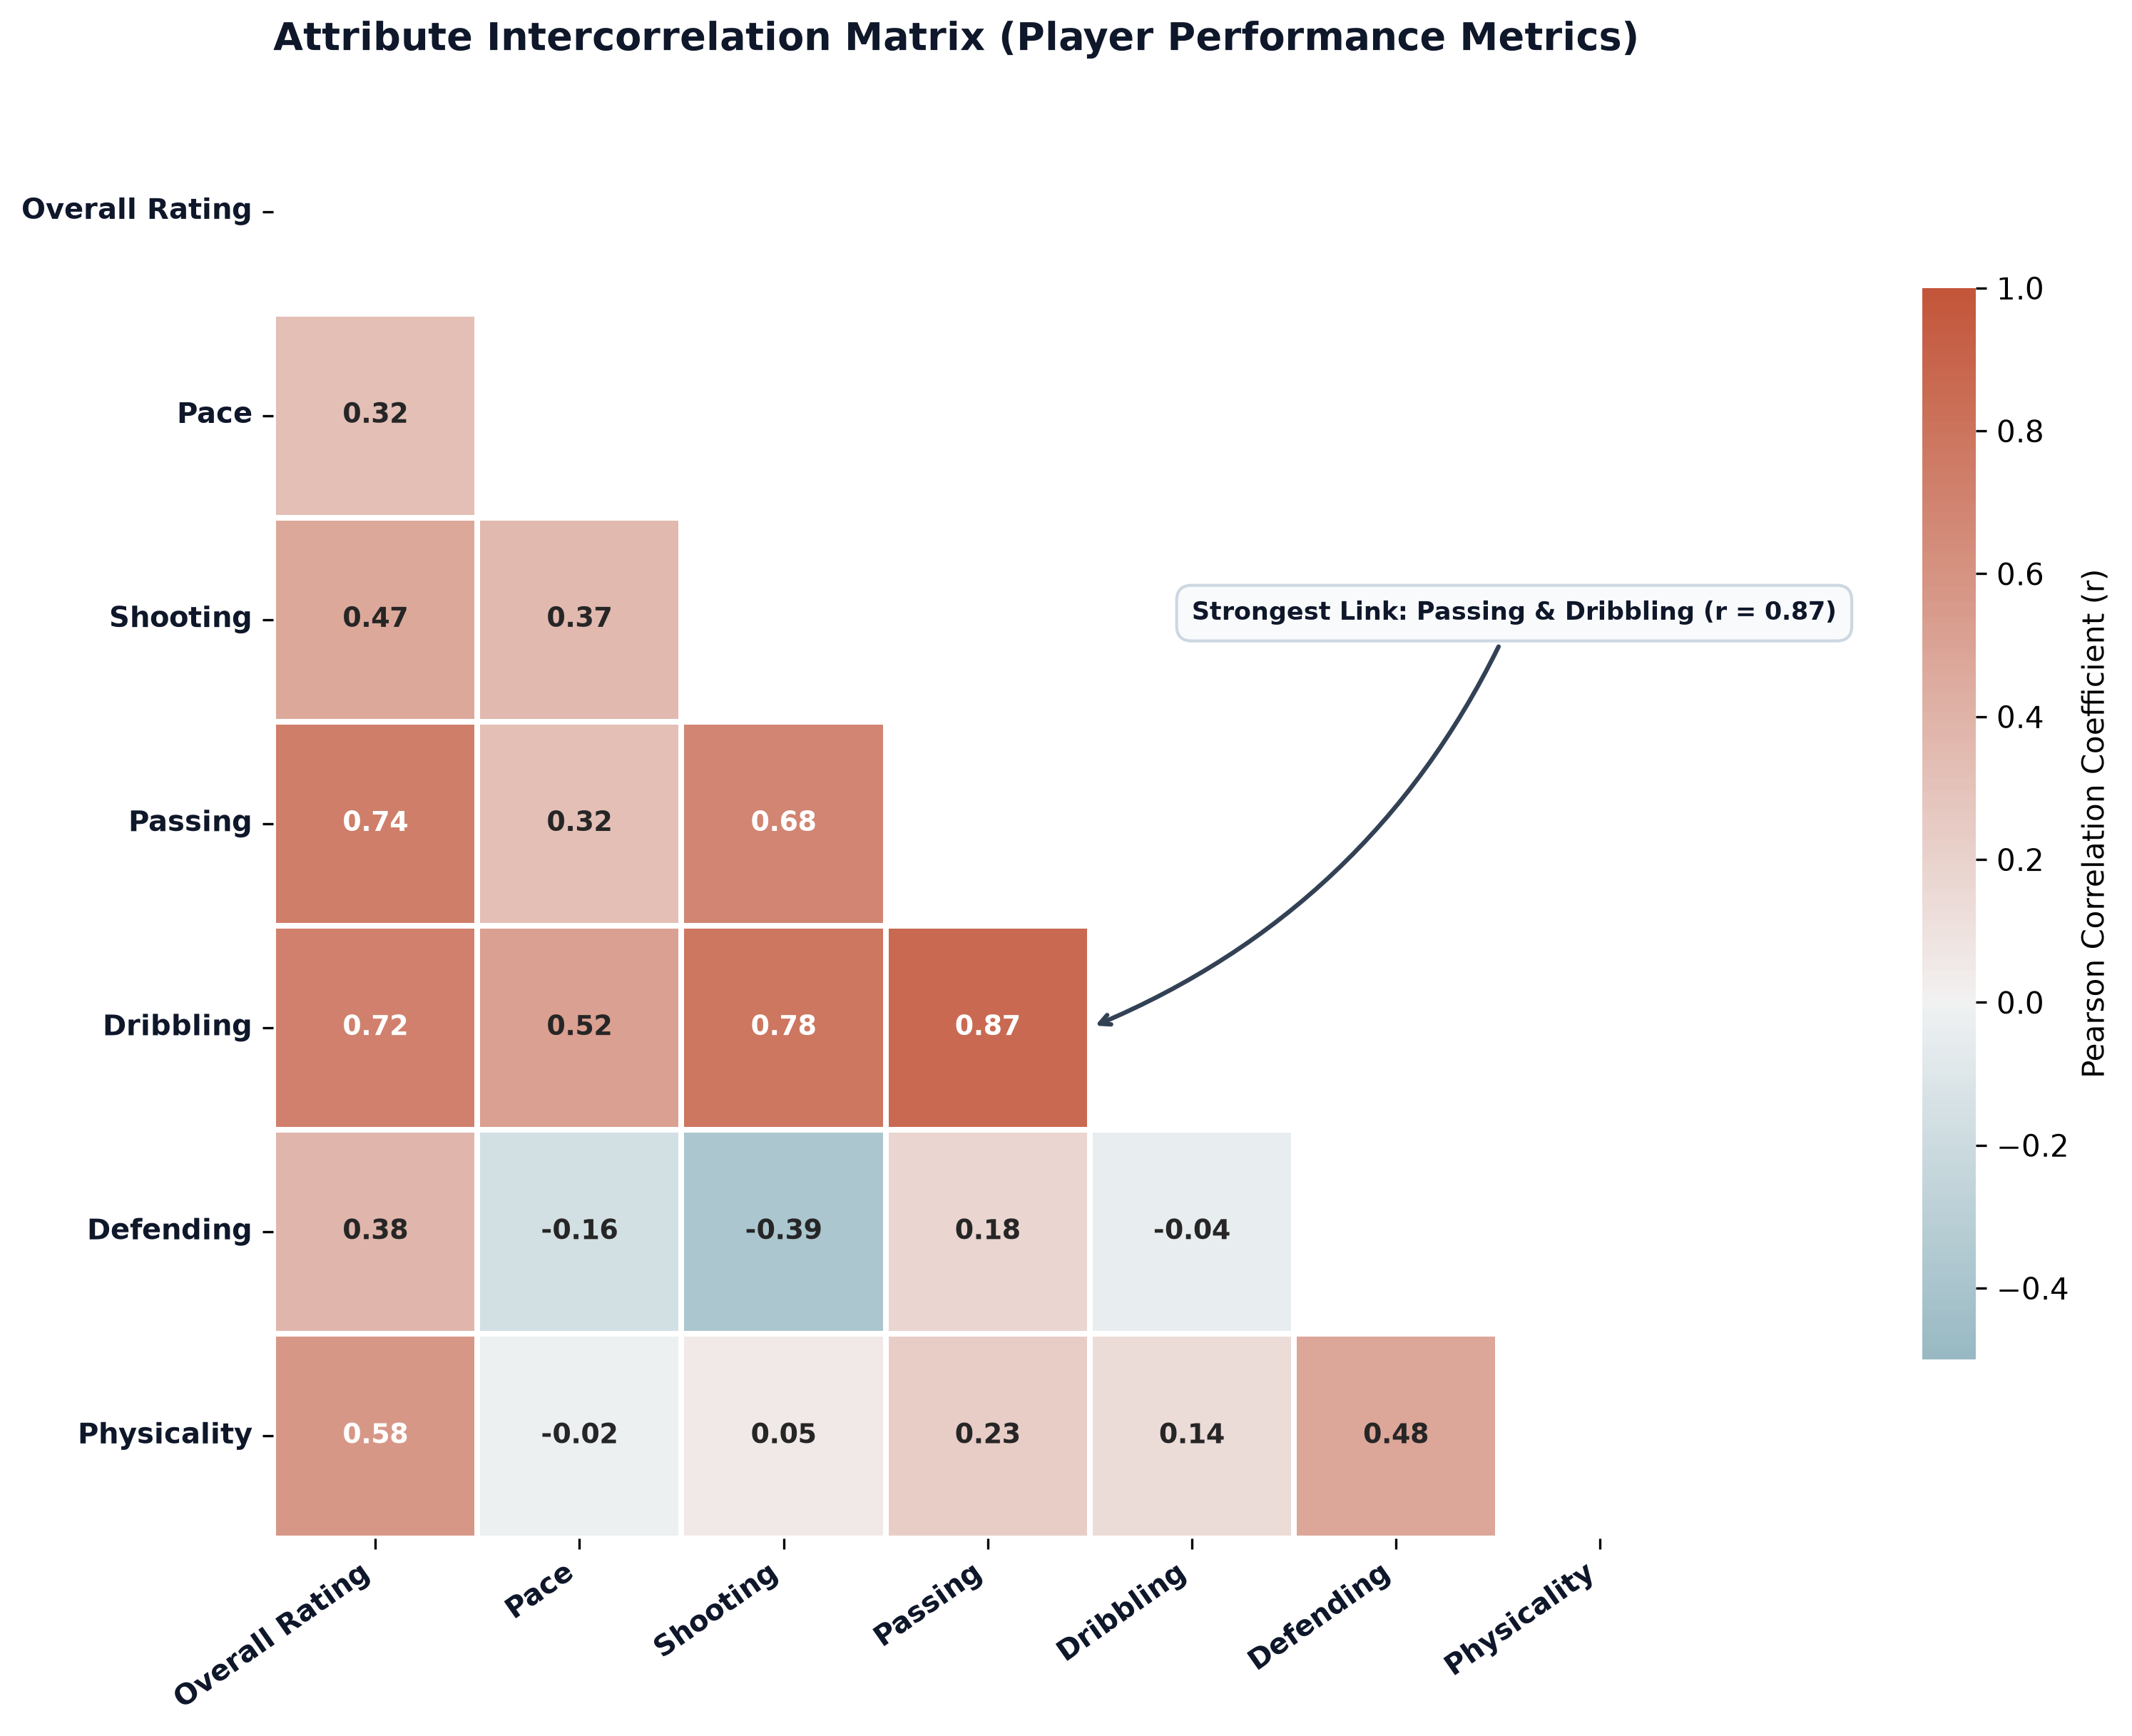

In [37]:
labels = [col.replace("_", " ").title() for col in cm.columns]

mask = np.triu(np.ones_like(cm, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8), dpi=300, layout="constrained")
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

cmap = sns.diverging_palette(220, 20, as_cmap=True)

sns.heatmap(
    cm,
    mask=mask,
    cmap=cmap,
    vmax=1.0,
    vmin=-0.5,
    center=0,
    square=True,
    linewidths=1.5,
    cbar_kws={"shrink": 0.75, "label": "Pearson Correlation Coefficient (r)"},
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9, "weight": "bold"},
    ax=ax,
)

ax.set_xticklabels(
    labels,
    rotation=35,
    ha="right",
    fontsize=9.5,
    fontweight="bold",
    color="#0f172a",
)
ax.set_yticklabels(
    labels,
    rotation=0,
    fontsize=9.5,
    fontweight="bold",
    color="#0f172a",
)

ax.set_title(
    "Attribute Intercorrelation Matrix (Player Performance Metrics)",
    fontsize=13,
    fontweight="bold",
    color="#0f172a",
    pad=20,
    loc="left",
)

ax.annotate(
    "Strongest Link: Passing & Dribbling (r = 0.87)",
    xy=(4, 4.5),
    xytext=(4.5, 2.5),
    fontsize=8.5,
    fontweight="bold",
    color="#0f172a",
    bbox={
        "boxstyle": "round,pad=0.6",
        "facecolor": "#f8fafc",
        "edgecolor": "#cbd5e1",
        "alpha": 0.95,
    },
    arrowprops={
        "arrowstyle": "->",
        "color": "#334155",
        "linewidth": 1.5,
        "connectionstyle": "arc3,rad=-0.2",
    },
)

plt.show()